In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from matplotlib import rcParams
config = {"mathtext.fontset":'stix'}
rcParams.update(config)
from matplotlib import cm
from matplotlib.collections import LineCollection

In [7]:
def P(data):
    date_array = np.array(data).reshape(1,-1)
    date_list = date_array[0].tolist()
    return date_list

def bar_show(x,y,out_file,bond_label):#width过小,很可能就没有显示!!1
    fig, ax = plt.subplots()
    ax.grid(False)
    map_vir = cm.get_cmap(name='brg')
#    norm = plt.Normalize(np.array(y).min(),np.array(y).max())
    norm = plt.Normalize(0,0.02)
    norm_y = norm(y)
    color = map_vir(norm_y)

    plt.bar(x, y, color='#f84d4d')
    k_value = np.sum(y)
    for x, y,z in zip(x, y,bond_label):
        if y > 0.0005:
            plt.text(x, y+0.0001, '%s' % str(z), ha='center', va='bottom',rotation=90, fontsize=10.5,fontname="Times New Roman")
                
    legend = plt.legend(loc='best',title='      '+str(out_file)+'\n'+'$\it\kappa$ = '+f'{k_value:.3f}')
    legend.get_title().set_fontsize(fontsize = 16)
    legend.get_title().set_fontname(fontname="Times New Roman")
    
    plt.yticks(fontsize=16,fontname="Times New Roman")
    plt.ylabel('$\it\kappa$',fontsize=20,fontname="Times New Roman")
        
    ax=plt.gca();#获得坐标轴的句柄
    ax.spines['bottom'].set_linewidth(2);###设置底部坐标轴的粗细
    ax.spines['left'].set_linewidth(2);####设置左边坐标轴的粗细
    ax.spines['right'].set_linewidth(2);###设置右边坐标轴的粗细
    ax.spines['top'].set_linewidth(2);####设置上部坐标轴的粗细  
        
    plt.xlim(-2, 45)
    plt.ylim(0, 0.008)
    ax.axes.xaxis.set_ticklabels([])
    plt.xticks([])

    my_y_ticks = np.arange(0,0.0080001,0.002) # 横坐标设置0,2,...,len(acc)-1，间隔为2
    plt.yticks(my_y_ticks) 
    
    plt.show()
    svg_name = out_file+'.svg'
    png_name = out_file+'.png'
    fig.savefig(svg_name, format='svg',bbox_inches = 'tight')
    fig.savefig(png_name, dpi=1200,format='png',bbox_inches = 'tight')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


eta: 0.057
phi: -0.017
kappa: 0.040


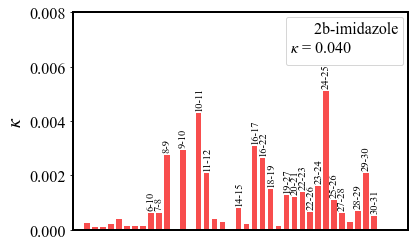

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


eta: 0.055
phi: -0.023
kappa: 0.033


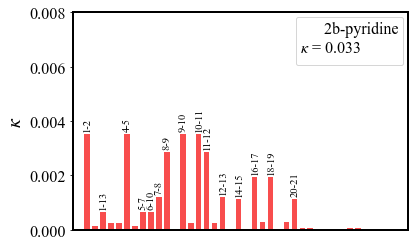

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


eta: 0.058
phi: -0.014
kappa: 0.044


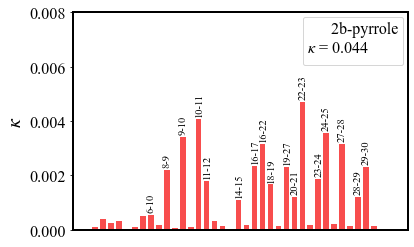

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


eta: 0.054
phi: -0.018
kappa: 0.036


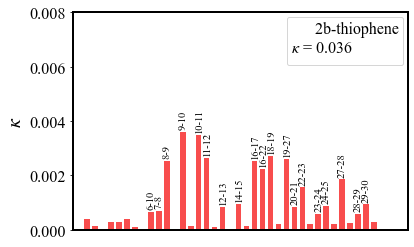

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


eta: 0.052
phi: -0.008
kappa: 0.044


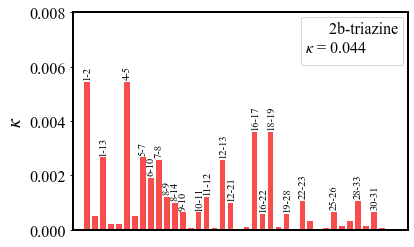

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


eta: 0.070
phi: -0.016
kappa: 0.054


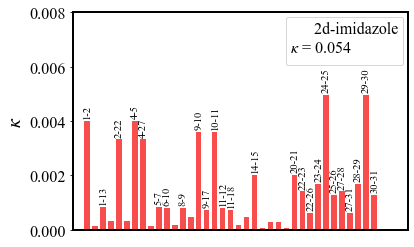

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


eta: 0.057
phi: -0.025
kappa: 0.032


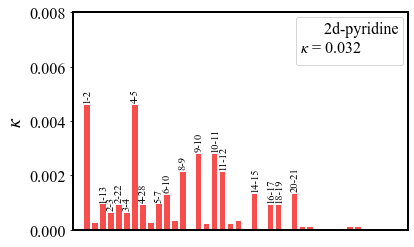

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


eta: 0.069
phi: -0.015
kappa: 0.054


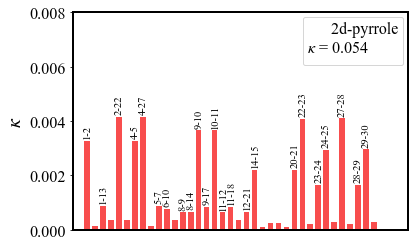

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


eta: 0.067
phi: -0.019
kappa: 0.048


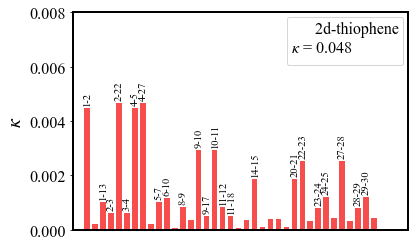

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


eta: 0.044
phi: -0.019
kappa: 0.025


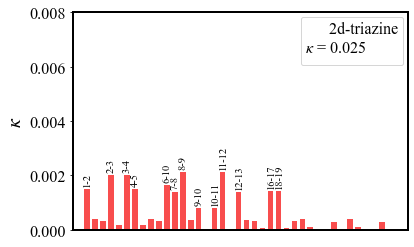

In [8]:
#多轨道跃迁
def BOBL_out(file):
    f = open(file,'r')
    line = f.readlines()

    for index,lines in enumerate(line):
        if "eta_value:" in lines:
            eta_idx = index        
        if "phi_value:" in lines:
            phi_idx = index          
        
        if "Bond" in lines:
            idx_bond = index
        if "HOMO" in lines:
            idx_homo = index
    
    trans_num = phi_idx - eta_idx
    
    label1 = np.loadtxt(file,skiprows=idx_bond,usecols=(0),max_rows=idx_homo-idx_bond-2,dtype=str)
    label1 = [x[1:-1] for x in label1]
    label2 = np.loadtxt(file,skiprows=idx_bond,usecols=(1),max_rows=idx_homo-idx_bond-2,dtype=str)
    label2 = [x[0:-1] for x in label2]
    label = []
    for i in range(len(label1)):
        label.append(label1[i]+'-'+label2[i])
    
    eta_inital = []
    eta_final = []
    phi = []
    for i in range(trans_num):
        eta_inital.append(np.loadtxt(file,skiprows=idx_bond,usecols=(2+i),max_rows=idx_homo-idx_bond-2))
        eta_final.append(np.loadtxt(file,skiprows=idx_bond,usecols=(2+trans_num+i),max_rows=idx_homo-idx_bond-2))
        phi.append(np.loadtxt(file,skiprows=idx_bond,usecols=(2+2*trans_num+i),max_rows=idx_homo-idx_bond-2))
    eta_inital = sum(eta_inital)
    eta_final = sum(eta_final)
    phi = sum(phi)
#    print(eta_inital,eta_final)
    eta_value = eta_inital+eta_final
    phi_value = 2*phi
    k_value = eta_inital+eta_final+2*phi
    
    label_x = []
    for i in range(len(label)):
        label_x.append(i*1.12)

    print('eta: '+f'{np.sum(eta_value):.3f}')
    print('phi: '+f'{np.sum(phi_value):.3f}')
    print('kappa: '+f'{np.sum(k_value):.3f}')
    return label,k_value,label_x
# a=BOBL_out('2a-s0-nao.dat')
# bar_show(a[2],a[1],'2a',a[0])
os.chdir('./')
for filename in os.listdir('.'): 
    if filename.endswith('.dat'):
        data = BOBL_out(filename)
        bar_show(data[2],data[1],str(filename[0:-11]),data[0])

In [26]:
def delta_pz_show(x,y,out_file,bond_label):#width过小,很可能就没有显示!!1
    fig, ax = plt.subplots()
    ax.grid(False)
    map_vir = cm.get_cmap(name='bwr')
    norm = plt.Normalize(-0.1,0.1)
    norm_y = norm(y)
    color = map_vir(norm_y)

    plt.bar(x, y, color='#845EC2')
    k_value = np.sum(y)
    for x, y,z in zip(x, y,bond_label):
        if y > 0.01:
            plt.text(x+0.008,y+0.0038, '%s' % str(z), ha='center', va='bottom',rotation=90, fontsize=13.8,fontname="Times New Roman")
        if y < -0.01:
            if len(z)==1:
                plt.text(x+0.008, y-0.018, '%s' % str(z), ha='center', va='bottom',rotation=90, fontsize=13.8,fontname="Times New Roman")
            if len(z)==2:
                plt.text(x+0.008, y-0.035, '%s' % str(z), ha='center', va='bottom',rotation=90, fontsize=13.8,fontname="Times New Roman")  

                
    legend = plt.legend(loc='best',title=str(out_file))
    legend.get_title().set_fontsize(fontsize = 18)
    legend.get_title().set_fontname(fontname="Times New Roman")
    
#    plt.xticks(fontsize=16,fontname="Times New Roman",color='white')
    plt.yticks(fontsize=18,fontname="Times New Roman")
#    plt.xlabel('Bond Index',fontsize=16,fontname="Times New Roman")
    plt.ylabel('$\it\Delta$${p}_\mathregular{z}$',fontsize=20,fontname="Times New Roman")
        
    ax=plt.gca();#获得坐标轴的句柄
    ax.spines['bottom'].set_linewidth(2);###设置底部坐标轴的粗细
    ax.spines['left'].set_linewidth(2);####设置左边坐标轴的粗细
    ax.spines['right'].set_linewidth(2);###设置右边坐标轴的粗细
    ax.spines['top'].set_linewidth(2);####设置上部坐标轴的粗细  
        
    plt.xlim(-2, 25)
    plt.ylim(-0.25, 0.25)

    ax.axes.xaxis.set_ticklabels([])
    plt.xticks([])

    my_y_ticks = np.arange(-0.2,0.201,0.1) # 横坐标设置0,2,...,len(acc)-1，间隔为2
    plt.yticks(my_y_ticks) 
    
    plt.show()
    svg_name = str(out_file)[0:4]+str(out_file)[5:-1]+'.svg'
    png_name = str(out_file)[0:4]+str(out_file)[5:-1]+'.png'
    fig.savefig(svg_name,format='svg',bbox_inches = 'tight')
    fig.savefig(png_name, dpi=1200,format='png',bbox_inches = 'tight')

In [15]:
def BOBL_pz_out(file):
    f = open(file,'r')
    line = f.readlines()

    for index,lines in enumerate(line):
        if "HOMO" in lines:
            idx_homo = index
        if "LUMO" in lines:
            idx_lumo = index
            
    label = np.loadtxt(file,skiprows=idx_homo+1,usecols=(0),max_rows=idx_lumo-idx_homo-2,dtype=int)
    
    pz_homo = np.loadtxt(file,skiprows=idx_homo+1,usecols=(1),max_rows=idx_lumo-idx_homo-2)
    pz_lumo = np.loadtxt(file,skiprows=idx_lumo+1,usecols=(1),max_rows=idx_lumo-idx_homo-2)

        
    return label,pz_homo,pz_lumo

In [12]:
BOBL_pz_out('2a-s0-nao.dat')

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21]),
 array([ 0.21701,  0.40234,  0.     , -0.40234,  0.21701,  0.     ,
        -0.31974,  0.18062,  0.20754, -0.     ,  0.20754,  0.18062,
        -0.31974,  0.18693, -0.06852, -0.25306, -0.08472, -0.08472,
        -0.25306, -0.06852,  0.18693]),
 array([ 0.22193,  0.0638 , -0.27633,  0.0638 , -0.22193,  0.0466 ,
         0.16612, -0.17313,  0.11771, -0.517  , -0.11771,  0.17313,
        -0.16612, -0.17842,  0.27965,  0.04511, -0.2825 ,  0.2825 ,
        -0.04511, -0.27965,  0.17842]))

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


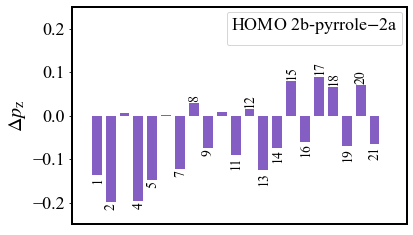

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


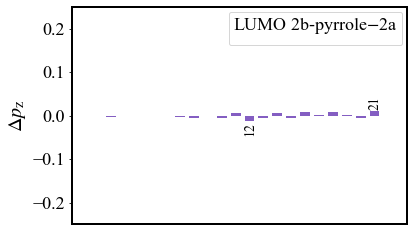

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


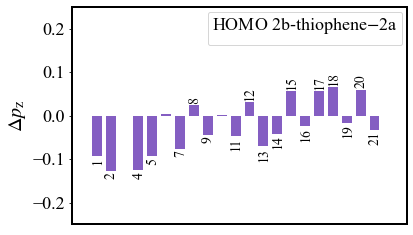

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


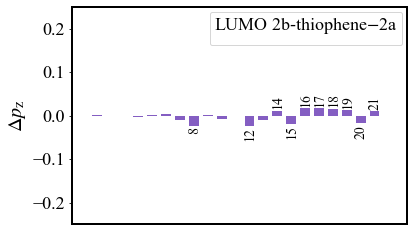

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


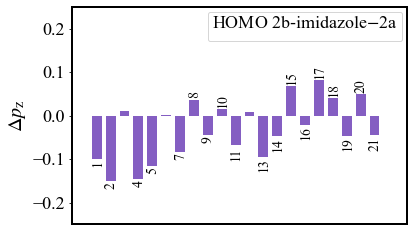

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


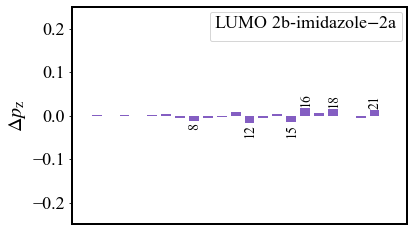

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


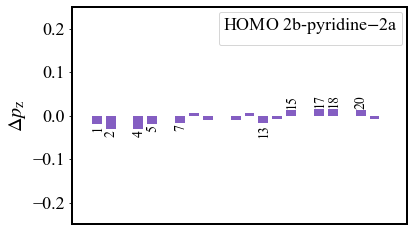

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


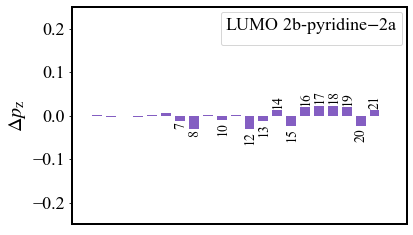

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


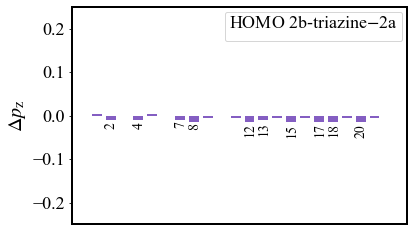

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


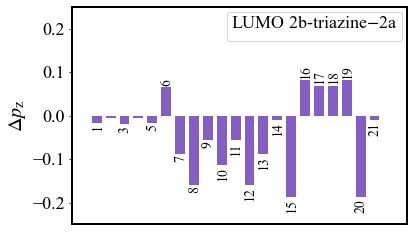

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


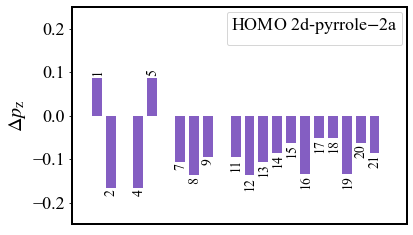

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


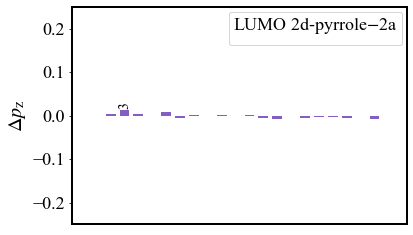

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


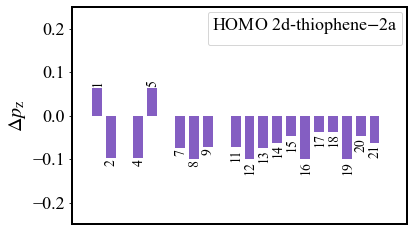

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


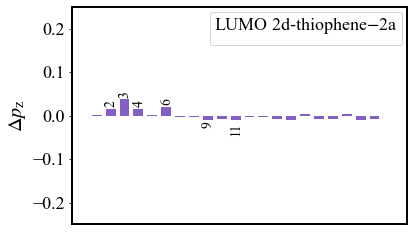

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


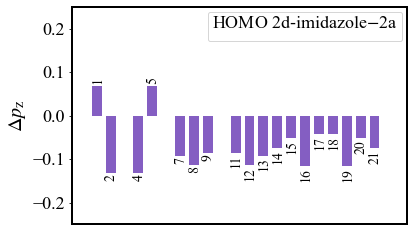

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


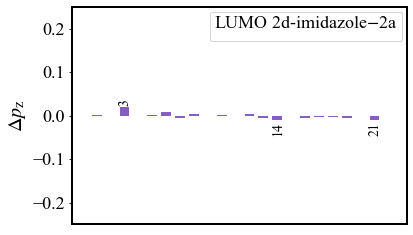

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


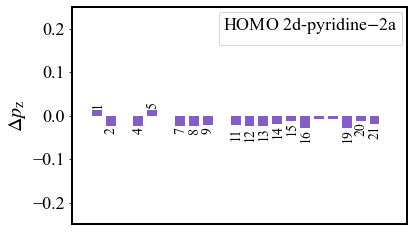

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


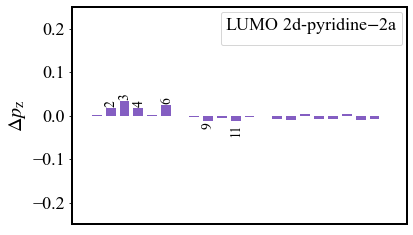

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


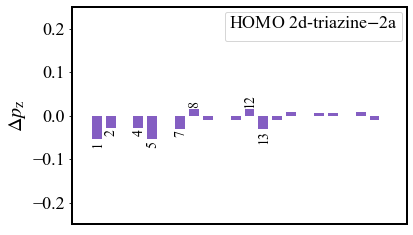

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


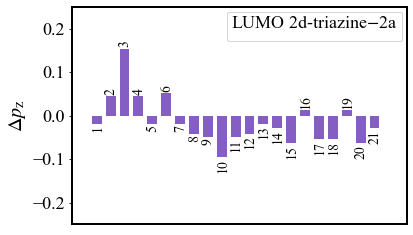

In [29]:
def delta_pz(new_file,old_file):
    new_data = BOBL_pz_out(new_file)
    old_data = BOBL_pz_out(old_file) 
    
    delta_homo_pz = []
    delta_lumo_pz = []
    for i in range(len(new_data[0])):
        for j in range(len(old_data[0])):
            if new_data[0][i] == old_data[0][j]:
                delta_homo_pz.append([new_data[0][i],np.abs(new_data[1][i])-np.abs(old_data[1][j])])
                delta_lumo_pz.append([new_data[0][i],np.abs(new_data[2][i])-np.abs(old_data[2][j])])
                
    for i in range(len(new_data[0])):
        if new_data[0][i] not in old_data[0]:
            delta_homo_pz.append([new_data[0][i],new_data[1][i]])
            delta_lumo_pz.append([new_data[0][i],new_data[2][i]])            
                
    label_x = []
    for i in range(len(old_data[0])):
        label_x.append(i*1.12)
        

    return [str(x) for x in new_data[0]][0:len(old_data[0])],np.array(delta_homo_pz)[:,1:2].flatten()[0:len(old_data[0])].astype('float64'),\
np.array(delta_lumo_pz)[:,1:2].flatten()[0:len(old_data[0])].astype('float64'),label_x


b_pyrrole_delta_pz = delta_pz('2b-pyrrole-s0-nao.dat','2a-s0-nao.dat')                   
delta_pz_show(b_pyrrole_delta_pz[3],b_pyrrole_delta_pz[1],'HOMO 2b-pyrrole$-$2a',b_pyrrole_delta_pz[0])
delta_pz_show(b_pyrrole_delta_pz[3],b_pyrrole_delta_pz[2],'LUMO 2b-pyrrole$-$2a',b_pyrrole_delta_pz[0])

b_thiophene_delta_pz = delta_pz('2b-thiophene-s0-nao.dat','2a-s0-nao.dat')                   
delta_pz_show(b_thiophene_delta_pz[3],b_thiophene_delta_pz[1],'HOMO 2b-thiophene$-$2a',b_thiophene_delta_pz[0])
delta_pz_show(b_thiophene_delta_pz[3],b_thiophene_delta_pz[2],'LUMO 2b-thiophene$-$2a',b_thiophene_delta_pz[0])

b_imidazole_delta_pz = delta_pz('2b-imidazole-s0-nao.dat','2a-s0-nao.dat')                   
delta_pz_show(b_imidazole_delta_pz[3],b_imidazole_delta_pz[1],'HOMO 2b-imidazole$-$2a',b_imidazole_delta_pz[0])
delta_pz_show(b_imidazole_delta_pz[3],b_imidazole_delta_pz[2],'LUMO 2b-imidazole$-$2a',b_imidazole_delta_pz[0])

b_pyridine_delta_pz = delta_pz('2b-pyridine-s0-nao.dat','2a-s0-nao.dat')                   
delta_pz_show(b_pyridine_delta_pz[3],b_pyridine_delta_pz[1],'HOMO 2b-pyridine$-$2a',b_pyridine_delta_pz[0])
delta_pz_show(b_pyridine_delta_pz[3],b_pyridine_delta_pz[2],'LUMO 2b-pyridine$-$2a',b_pyridine_delta_pz[0])

b_triazine_delta_pz = delta_pz('2b-triazine-s0-nao.dat','2a-s0-nao.dat')                   
delta_pz_show(b_triazine_delta_pz[3],b_triazine_delta_pz[1],'HOMO 2b-triazine$-$2a',b_triazine_delta_pz[0])
delta_pz_show(b_triazine_delta_pz[3],b_triazine_delta_pz[2],'LUMO 2b-triazine$-$2a',b_triazine_delta_pz[0])



d_pyrrole_delta_pz = delta_pz('2d-pyrrole-s0-nao.dat','2a-s0-nao.dat')                   
delta_pz_show(d_pyrrole_delta_pz[3],d_pyrrole_delta_pz[1],'HOMO 2d-pyrrole$-$2a',d_pyrrole_delta_pz[0])
delta_pz_show(d_pyrrole_delta_pz[3],d_pyrrole_delta_pz[2],'LUMO 2d-pyrrole$-$2a',d_pyrrole_delta_pz[0])

d_thiophene_delta_pz = delta_pz('2d-thiophene-s0-nao.dat','2a-s0-nao.dat')                   
delta_pz_show(d_thiophene_delta_pz[3],d_thiophene_delta_pz[1],'HOMO 2d-thiophene$-$2a',d_thiophene_delta_pz[0])
delta_pz_show(d_thiophene_delta_pz[3],d_thiophene_delta_pz[2],'LUMO 2d-thiophene$-$2a',d_thiophene_delta_pz[0])

d_imidazole_delta_pz = delta_pz('2d-imidazole-s0-nao.dat','2a-s0-nao.dat')                   
delta_pz_show(d_imidazole_delta_pz[3],d_imidazole_delta_pz[1],'HOMO 2d-imidazole$-$2a',d_imidazole_delta_pz[0])
delta_pz_show(d_imidazole_delta_pz[3],d_imidazole_delta_pz[2],'LUMO 2d-imidazole$-$2a',d_imidazole_delta_pz[0])

d_pyridine_delta_pz = delta_pz('2d-pyridine-s0-nao.dat','2a-s0-nao.dat')                   
delta_pz_show(d_pyridine_delta_pz[3],d_pyridine_delta_pz[1],'HOMO 2d-pyridine$-$2a',d_pyridine_delta_pz[0])
delta_pz_show(d_pyridine_delta_pz[3],d_pyridine_delta_pz[2],'LUMO 2d-pyridine$-$2a',d_pyridine_delta_pz[0])

d_triazine_delta_pz = delta_pz('2d-triazine-s0-nao.dat','2a-s0-nao.dat')                   
delta_pz_show(d_triazine_delta_pz[3],d_triazine_delta_pz[1],'HOMO 2d-triazine$-$2a',d_triazine_delta_pz[0])
delta_pz_show(d_triazine_delta_pz[3],d_triazine_delta_pz[2],'LUMO 2d-triazine$-$2a',d_triazine_delta_pz[0])

In [30]:
#python将svg格式转为emf格式
#安装inkscape的时候记得加到路径中
import numpy as np
import subprocess, os

def svg_to_emf(svg_figpath):
    if True:
        cwd_path = os.getcwd()
        svg_figpath = os.path.join(cwd_path, svg_figpath)
    #   print(svg_figpath)
    # inkscape.exe的绝对路径
    inkscape_path = 'D:\\work_setup\\lnkscape\\Inkscape\\bin\\inkscape.exe' 
    if svg_figpath is not None:
        path, svgfigname = os.path.split(svg_figpath)
        figname, figform = os.path.splitext(svgfigname)
        emf_figpath = os.path.join(path, figname + '.emf')
        subprocess.call("{} {} -T -o {}".format(inkscape_path, svg_figpath, emf_figpath), shell=True)
        # os.remove(svg_figpath)
        
svgFiles = []
for filename in os.listdir('.'): 
    if filename.endswith('.svg'):
        svgFiles.append(filename)
        
for i in svgFiles:
    svg_to_emf(i)
    os.remove(i)